In [1]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from scdepth import pl, fn, fit
from scipy import stats
import glob, os

In [2]:
cdf = pd.read_csv('../data/cohort.csv')
adf = pd.read_csv('../data/cohort_annotations.csv')
cdf = cdf.merge(adf, left_on=['group','subgroup'], right_on=['group','subgroup'], how='left')


In [3]:
vdf = []
sdf = []


for i, r in cdf.iterrows():
    ch = r.dataset

    fn = f'../{ch}/{r["sample"]}/scdepth_genes_summary.txt'

    bn = f'../{ch}/{r["sample"]}/scdepth_fit_baseline.txt'

    if not os.path.isfile(fn):
        continue

    #df = pd.read_csv(bn, sep='\t').iloc[0]
    bdf = pd.read_csv(fn, sep='\t')
    bdf.insert(0, 'sample', value=r['sample'])
    bdf['group'] = r['group']
    bdf['subgroup'] = r['subgroup']
    bdf['dataset'] = r['dataset']
    bdf['color'] = r['color']
    bdf['title'] = r['subgroup_title']
    bdf['order'] = r['order']

    
    if 'visium_hd' in r['group']:
        vdf.append(bdf)
    else:
        sdf.append(bdf)

vdf = pd.concat(vdf)
sdf = pd.concat(sdf)

28


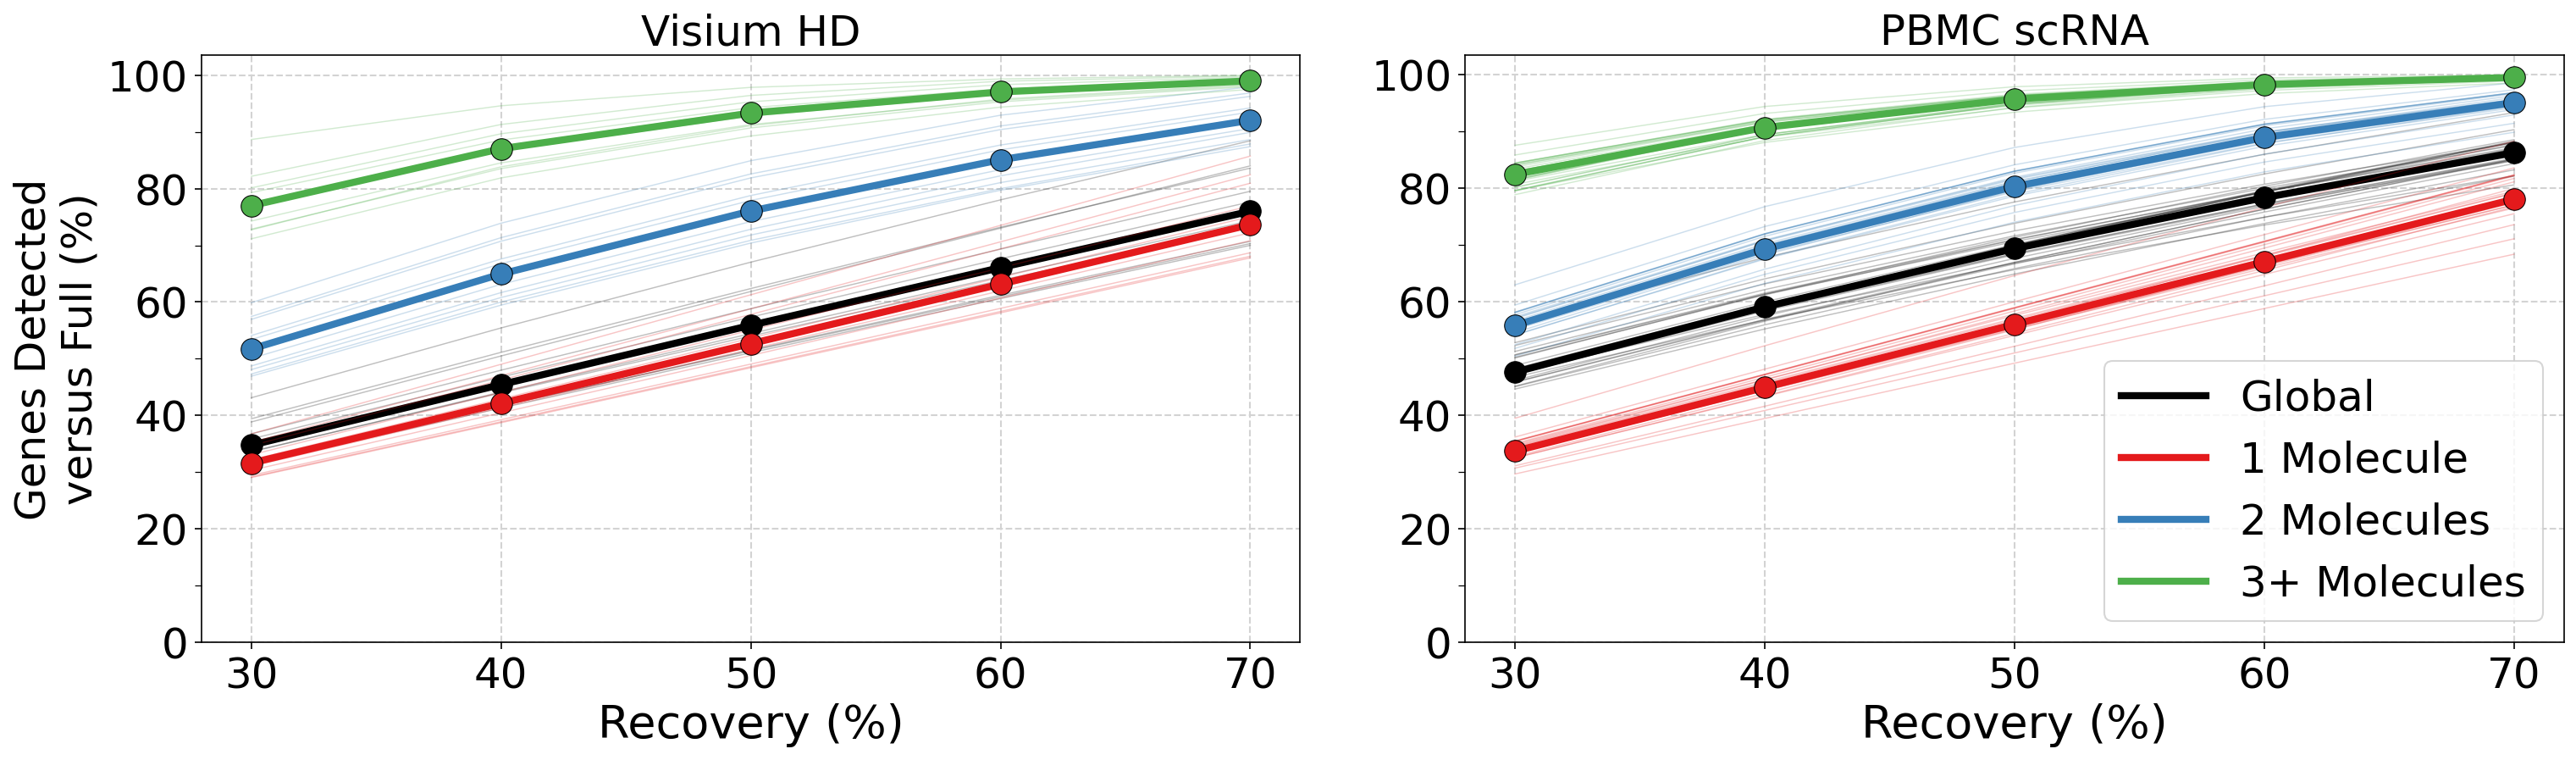

In [7]:
from matplotlib.lines import Line2D
fig, axs = pl.figax(1, 2, w=12, h=6)
fig.subplots_adjust(wspace=0.15)
seen = set()
print(len(set(sdf['sample'].values)))

pref = 'stability'
labels = ('Global', '1 Molecule', '2 Molecules', '3+ Molecules')
colors = ('k', plt.cm.Set1.colors[0], plt.cm.Set1.colors[1], plt.cm.Set1.colors[2])

for ax, ddf in zip(axs, (vdf, sdf)):
    for j, (suff, lab, color) in enumerate(zip(('', '_1', '_2', '_3p'), labels, colors)):
        pts = {}
        for s, df in ddf.groupby('sample'):
            adf = cdf[cdf['sample'] == s].iloc[0]
            df = df.sort_values(['recovery'])
        
            m = 'o' #if 'flex' in adf.subgroup else 'D'
        
    
            l = '_'
            if (pref, lab) not in seen:
                l = lab
                seen.add((pref, l))
            ls = '-'
            
            ax.plot(df['recovery'], 100*df[pref + suff], lw=0.7, color=color, label=l, ls=ls, zorder=8, alpha=0.25)
            #ax.scatter(df['recovery'], 100*df[pref + suff], s=25, edgecolor='k', lw=0.5, color=plt.cm.Set1.colors[j], zorder=10, marker=m, alpha=0.75)
        med = ddf[['recovery', pref + suff]].groupby('recovery').median()
        ax.plot(med.index, 100*med[pref + suff], lw=4, color=color, label=lab, ls=ls, zorder=8, alpha=1)
        ax.scatter(med.index, 100*med[pref + suff], s=150, edgecolor='k', lw=0.5, color=color, zorder=10, marker=m, alpha=1)
    
    for ax in axs:    
        ax.set_xlabel('Recovery (%)', fontsize=26)
        ax.set_xticks(np.arange(30, 75, 10))
        
        ax.set_yticks(np.arange(0, 105, 20))
        ax.set_yticks(np.arange(0, 105, 10), minor=True)
        
        ax.tick_params(axis='both', labelsize=24)
        ax.tick_params(axis='both', which='both', length=4)
        
        ax.grid(axis='both', color='lightgray', ls='--', lw=1, which='major')
        ax.set_axisbelow(True)
        
axs[0].set_title('Visium HD', fontsize=24)
axs[1].set_title('PBMC scRNA', fontsize=24)
axs[1].legend(loc = 'lower right', fontsize=24)
axs[0].set_ylabel('Genes Detected Stability\nversus Full (%)', fontsize=24)
fig.savefig('../Figures/Figure 4C Stability.svg', bbox_inches='tight')

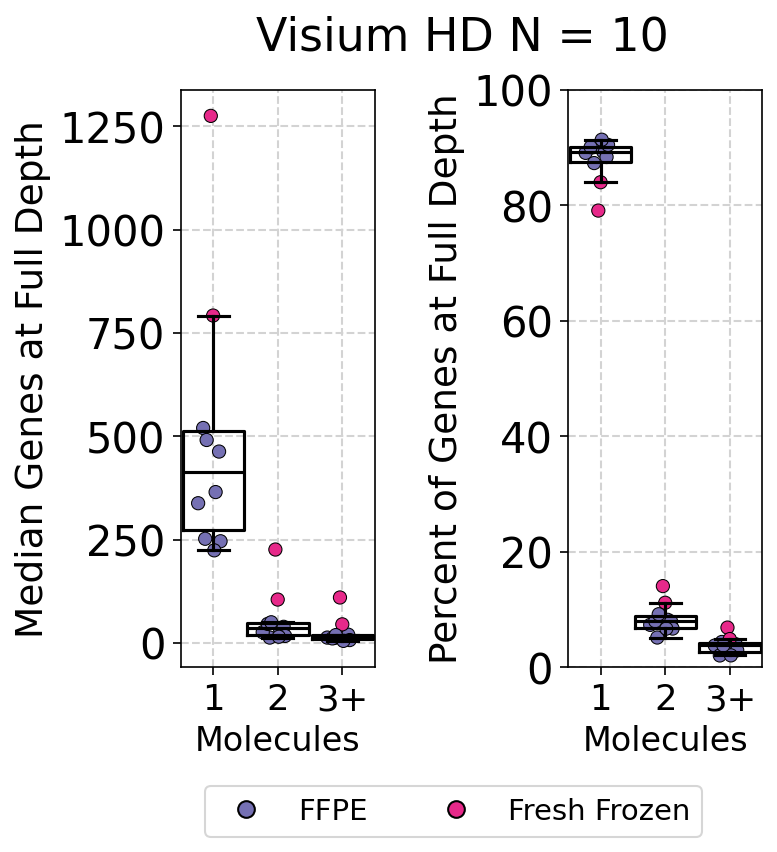

In [5]:
fig, axs = pl.figax(1, 2, h=5, w=2.5)
fig.subplots_adjust(wspace=1)
vs = vdf[vdf['recovery'] == 30]

pl.jitter_box(axs[0], 0, vs['genes_1'], c=vs.color, s=40, blw=1.5, mlw=1.5, wlw=1.5, plw=1.5, edgecolor='k', lw=0.5)
pl.jitter_box(axs[0], 1, vs['genes_2'], c=vs.color, s=40, blw=1.5, mlw=1.5, wlw=1.5, plw=1.5, edgecolor='k', lw=0.5)
pl.jitter_box(axs[0], 2, vs['genes_3p'], c=vs.color, s=40, blw=1.5, mlw=1.5, wlw=1.5, plw=1.5, edgecolor='k', lw=0.5)

pl.jitter_box(axs[1], 0, vs['fgenes_1'], c=vs.color, s=40, blw=1.5, mlw=1.5, wlw=1.5, plw=1.5, edgecolor='k', lw=0.5)
pl.jitter_box(axs[1], 1, vs['fgenes_2'], c=vs.color, s=40, blw=1.5, mlw=1.5, wlw=1.5, plw=1.5, edgecolor='k', lw=0.5)
pl.jitter_box(axs[1], 2, vs['fgenes_3p'], c=vs.color, s=40, blw=1.5, mlw=1.5, wlw=1.5, plw=1.5, edgecolor='k', lw=0.5)

axs[0].set_ylabel('Median Genes at Full Depth', fontsize=18)

for ax in axs:    
    ax.grid(axis='both', color='lightgray', ls='--', lw=1, which='major')
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=20)
    ax.tick_params(axis='both', which='both', length=4)
    
    ax.set_xticklabels(['1','2','3+'], fontsize=17)
    ax.set_xlabel('Molecules', fontsize=16)
fig.suptitle(f'Visium HD N = {vdf["sample"].nunique()}', fontsize=22, y=0.98)

vhandles = []
vl = vdf[['title','color','order']].drop_duplicates().sort_values('order')

for t in vl.itertuples():
    vhandles.append(Line2D([0], [0], marker='o', color=t.color,
           lw=0, label=t.title, markeredgecolor='k', markersize=8))
lgd = axs[0].legend(handles=vhandles, loc = 'upper left', fontsize=14, bbox_to_anchor=(0.05, -0.18), ncol=2)
axs[1].set_ylim(0, 100)
axs[1].set_ylabel('Percent of Genes at Full Depth', fontsize=18)

fig.savefig('../Figures/Figure 4A Visium HD Stats.svg', bbox_inches='tight', bbox_extra_artists=(lgd,))

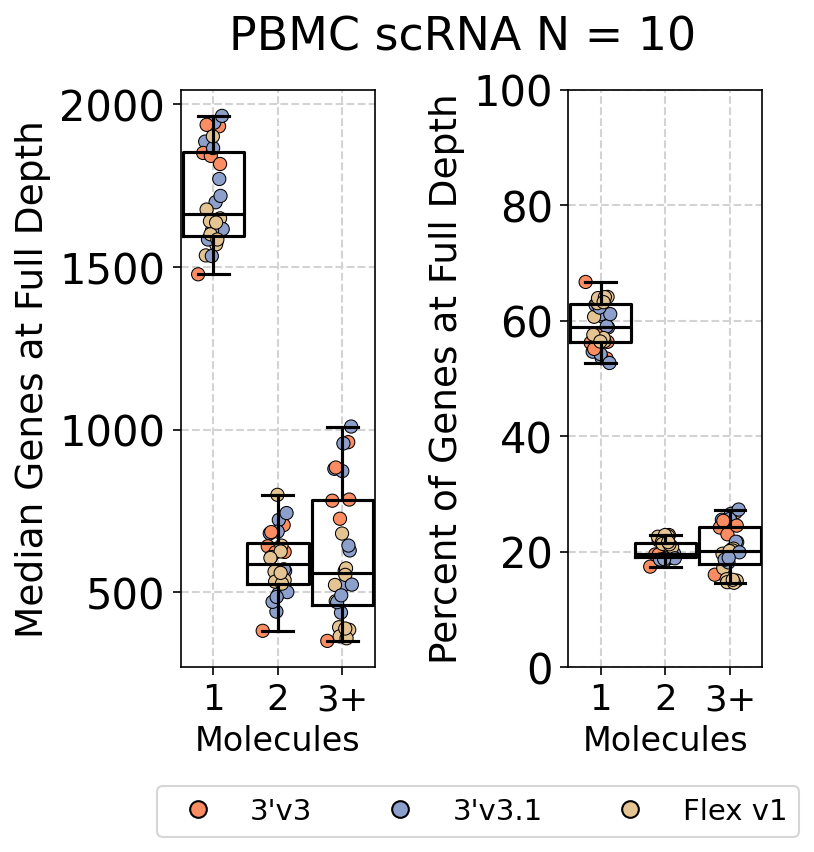

In [6]:
fig, axs = pl.figax(1, 2, h=5, w=2.5)
fig.subplots_adjust(wspace=1)
ss = sdf[sdf['recovery'] == 30]

pl.jitter_box(axs[0], 0, ss['genes_1'], c=ss.color, s=40, blw=1.5, mlw=1.5, wlw=1.5, plw=1.5, edgecolor='k', lw=0.5)
pl.jitter_box(axs[0], 1, ss['genes_2'], c=ss.color, s=40, blw=1.5, mlw=1.5, wlw=1.5, plw=1.5, edgecolor='k', lw=0.5)
pl.jitter_box(axs[0], 2, ss['genes_3p'], c=ss.color, s=40, blw=1.5, mlw=1.5, wlw=1.5, plw=1.5, edgecolor='k', lw=0.5)

pl.jitter_box(axs[1], 0, ss['fgenes_1'], c=ss.color, s=40, blw=1.5, mlw=1.5, wlw=1.5, plw=1.5, edgecolor='k', lw=0.5)
pl.jitter_box(axs[1], 1, ss['fgenes_2'], c=ss.color, s=40, blw=1.5, mlw=1.5, wlw=1.5, plw=1.5, edgecolor='k', lw=0.5)
pl.jitter_box(axs[1], 2, ss['fgenes_3p'], c=ss.color, s=40, blw=1.5, mlw=1.5, wlw=1.5, plw=1.5, edgecolor='k', lw=0.5)

axs[0].set_ylabel('Median Genes at Full Depth', fontsize=18)

for ax in axs:    
    ax.grid(axis='both', color='lightgray', ls='--', lw=1, which='major')
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=20)
    ax.tick_params(axis='both', which='both', length=4)
    
    ax.set_xticklabels(['1','2','3+'], fontsize=17)
    ax.set_xlabel('Molecules', fontsize=16)


sl = sdf[['title','color','order']].drop_duplicates().sort_values('order')

shandles = []

for t in sl.itertuples():
    shandles.append(Line2D([0], [0], marker='o', color=t.color,
           lw=0, label=t.title, markeredgecolor='k', markersize=8))
fig.suptitle(f'PBMC scRNA N = {vdf["sample"].nunique()}', fontsize=22, y=0.98)


lgd = axs[0].legend(handles=shandles, loc = 'upper left', fontsize=14, bbox_to_anchor=(-0.2, -0.18), ncol=3)
axs[1].set_ylim(0, 100)
axs[1].set_ylabel('Percent of Genes at Full Depth', fontsize=18)
fig.savefig('../Figures/Figure 4B PBMC Stats.svg', bbox_inches='tight', bbox_extra_artists=(lgd,))